Out-of-Sample Prediction Metrics per Asset:
                 MSE        R2  Directional Accuracy  Spearman
es1_logret  0.000637 -0.007109              0.571885  0.057546
vg1_logret  0.000852 -0.003030              0.003195       NaN
z1_logret   0.000649 -0.013921              0.562300  0.186762
rx1_logret  0.000113 -0.003858              0.000000       NaN
gc1_logret  0.000458 -0.051622              0.517572  0.020081
co1_logret  0.003564 -0.022024              0.501597 -0.020704
hg1_logret  0.000972 -0.001815              0.000000       NaN
Optimized Portfolio Annualized Sharpe: 0.4376
Benchmark Portfolio Annualized Sharpe: 0.4813
S&P 500 Annualized Sharpe: 0.8495
Optimized Portfolio Max Drawdown: 21.71%
Benchmark Portfolio Max Drawdown: 29.61%
S&P 500 Max Drawdown: 31.81%


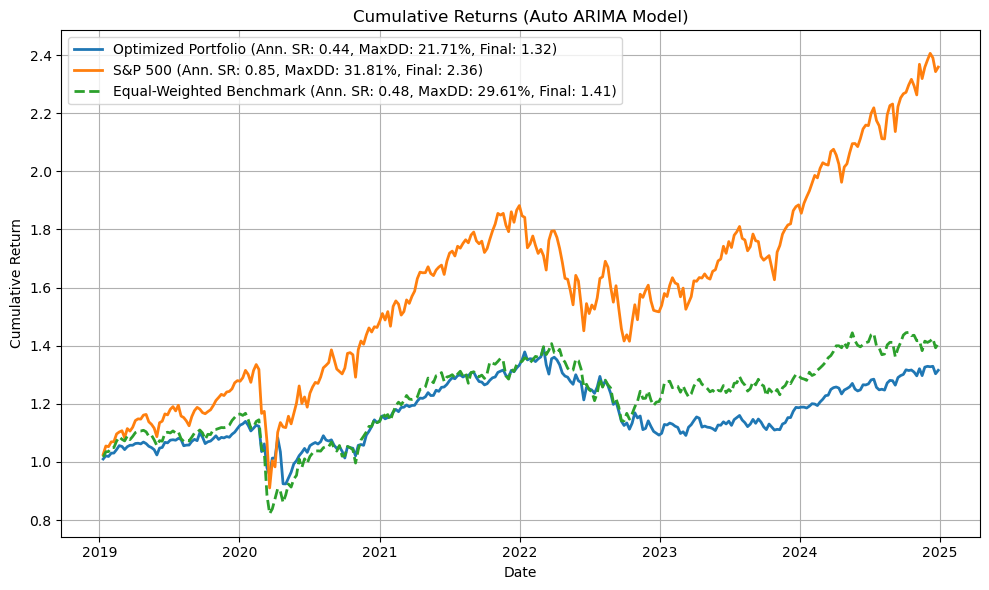


Final Cumulative Returns:
Optimized Portfolio Final Cumulative Return: 1.32
Benchmark Portfolio Final Cumulative Return: 1.41
S&P 500 Final Cumulative Return: 2.36

In-Sample Performance Metrics per Asset:
                 MSE        R2  Directional Accuracy  Spearman
es1_logret  0.000298  0.015109              0.560000  0.092888
vg1_logret  0.000548 -0.000470              0.010000       NaN
z1_logret   0.000457  0.015941              0.496667  0.132912
rx1_logret  0.000054 -0.002818              0.003333       NaN
gc1_logret  0.000415  0.032152              0.520000  0.154747
co1_logret  0.001700  0.014707              0.500000  0.103651
hg1_logret  0.000728 -0.000865              0.006667       NaN

Out-of-Sample Performance Metrics per Asset:
                 MSE        R2  Directional Accuracy  Spearman
es1_logret  0.000637 -0.007109              0.571885  0.057546
vg1_logret  0.000852 -0.003030              0.003195       NaN
z1_logret   0.000649 -0.013921              0.562300  

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pmdarima import auto_arima
import warnings
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
np.random.seed(42)
start_time = time.time()

###############################################################################
# 1. CVaR, Objective
###############################################################################
def compute_cvar(historical_returns, weights, alpha=0.9):
    port_returns = np.dot(historical_returns, weights)
    sorted_returns = np.sort(port_returns)
    cutoff = int(np.floor((1 - alpha) * len(sorted_returns)))
    cutoff = max(cutoff, 0)
    worst_returns = sorted_returns[:cutoff + 1]
    cvar = np.mean(worst_returns) if len(worst_returns) > 0 else sorted_returns[cutoff]
    return cvar

def cvar_objective(weights, predicted_returns, historical_returns, alpha=0.9, lambda_reg=0.01):
    eps = 1e-8
    port_return = np.dot(weights, predicted_returns)
    port_cvar = compute_cvar(historical_returns, weights, alpha=alpha)
    return -port_return / (abs(port_cvar) + eps) + lambda_reg * np.sum(weights**2)

###############################################################################
# 2. Data and Train/Test Split
###############################################################################
price_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\broader_weekly_data_filled.xlsx',
    parse_dates=["date"],
    index_col="date"
)
filtered_returns = price_data.iloc[:, :7]

train_start_date = '2013-04-01'
train_end_date   = '2018-12-31'
test_start_date  = '2019-01-01'
test_end_date    = '2025-01-01'

train_returns = filtered_returns.loc[train_start_date:train_end_date]
test_returns = filtered_returns.loc[test_start_date:test_end_date]
all_test_dates = test_returns.index

###############################################################################
# 3. Model training: auto_arima 
###############################################################################
arima_models = {}
in_sample_metrics = {}

for asset in train_returns.columns:
    model = auto_arima(
        train_returns[asset],
        seasonal=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    arima_models[asset] = model
    y_train_pred = model.predict_in_sample()
    y_train = train_returns[asset].iloc[-len(y_train_pred):] if len(y_train_pred) < len(train_returns[asset]) else train_returns[asset]

    in_sample_metrics[asset] = {
        "MSE": mean_squared_error(y_train, y_train_pred),
        "R2": r2_score(y_train, y_train_pred),
        "Directional Accuracy": np.mean(np.sign(y_train) == np.sign(y_train_pred)),
        "Spearman": spearmanr(y_train, y_train_pred)[0]
    }

###############################################################################
# 4. Generate Out-of-Sample Predictions using Rolling Forecast
###############################################################################
predictions = pd.DataFrame(index=test_returns.index, columns=test_returns.columns)

for asset in test_returns.columns:
    model = arima_models[asset]
    asset_preds = []
    for t in range(len(test_returns)):
        forecast = model.predict(n_periods=1)[0]
        asset_preds.append(forecast)
        model.update(test_returns[asset].iloc[t])
    predictions[asset] = asset_preds

###############################################################################
# 5. Compute Out-of-Sample Prediction Metrics per Asset
###############################################################################
out_sample_metrics = {}
for asset in test_returns.columns:
    y_true = test_returns[asset]
    y_pred = predictions[asset]
    mse_val = mean_squared_error(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)
    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    spearman_corr, _ = spearmanr(y_true, y_pred)

    out_sample_metrics[asset] = {
        "MSE": mse_val,
        "R2": r2_val,
        "Directional Accuracy": directional_accuracy,
        "Spearman": spearman_corr
    }

out_sample_metrics_df = pd.DataFrame(out_sample_metrics).T
print("Out-of-Sample Prediction Metrics per Asset:")
print(out_sample_metrics_df[['MSE', 'R2', 'Directional Accuracy', 'Spearman']])

###############################################################################
# 6. Optimization
###############################################################################
optimized_portfolio_returns = []
benchmark_returns = []
optimized_weights_list = []
prev_weights = np.ones(len(train_returns.columns)) / len(train_returns.columns)

for t in range(1, len(test_returns)):
    expected_returns = predictions.iloc[t-1].fillna(0).values
    historical_returns = train_returns.values

    n_assets = len(expected_returns)
    init_guess = np.ones(n_assets) / n_assets
    bounds = [(0, 1)] * n_assets
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: 0.4 - np.max(w)},
        {'type': 'ineq', 'fun': lambda w: np.min(w) - 0.0}
    ]

    # Rebalance every 2 periods
    if (t-1) % 2 == 0:
        res = minimize(
            cvar_objective,
            init_guess,
            args=(expected_returns, historical_returns, 0.95, 0.01),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )
        weights = res.x if res.success else init_guess
    else:
        weights = prev_weights

    turnover = np.sum(np.abs(weights - prev_weights))
    cost = 0.0001 * turnover
    realized_return = test_returns.iloc[t].values
    portfolio_return = np.dot(weights, realized_return)
    net_return = portfolio_return - cost

    optimized_portfolio_returns.append(net_return)
    benchmark_returns.append(np.dot(np.ones(n_assets) / n_assets, realized_return))
    optimized_weights_list.append(weights)
    prev_weights = weights.copy()

###############################################################################
# 7. Cumulative returns and performance metrics
###############################################################################
optimized_cumulative_returns = (1 + np.array(optimized_portfolio_returns)).cumprod()
benchmark_cumulative_returns = (1 + np.array(benchmark_returns)).cumprod()

def calculate_sharpe_ratio(returns, risk_free_rate=0):
    excess = np.array(returns) - risk_free_rate
    return np.mean(excess) / (np.std(excess, ddof=1) + 1e-9)

def calculate_max_drawdown(cum_returns):
    cum_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_max - cum_returns) / cum_max
    return np.max(drawdown)

sharpe_optimized_weekly = calculate_sharpe_ratio(optimized_portfolio_returns)
sharpe_benchmark_weekly = calculate_sharpe_ratio(benchmark_returns)
sharpe_sp_weekly = calculate_sharpe_ratio(test_returns.mean(axis=1).dropna())

sharpe_optimized = sharpe_optimized_weekly * np.sqrt(52)
sharpe_benchmark = sharpe_benchmark_weekly * np.sqrt(52)
sharpe_sp = sharpe_sp_weekly * np.sqrt(52)

max_drawdown_optimized = calculate_max_drawdown(optimized_cumulative_returns)
max_drawdown_benchmark = calculate_max_drawdown(benchmark_cumulative_returns)

final_optimized = optimized_cumulative_returns[-1]
final_benchmark = benchmark_cumulative_returns[-1]

###############################################################################
# 8. S&P 
###############################################################################
sp_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\sp_ret.xlsx',
    parse_dates=["date"],
    index_col="date"
)
sp_returns = sp_data['sp_ret']
sp_returns = sp_returns.loc[test_start_date:test_end_date]
sp_cumulative_returns = (1 + sp_returns).cumprod()
sp_cumulative_returns = sp_cumulative_returns.reindex(all_test_dates, method='ffill').dropna()

sharpe_sp = calculate_sharpe_ratio(sp_returns.dropna()) * np.sqrt(52)
max_drawdown_sp = calculate_max_drawdown(sp_cumulative_returns.values)
final_sp = sp_cumulative_returns.iloc[-1]

print(f"Optimized Portfolio Annualized Sharpe: {sharpe_optimized:.2f}")
print(f"Benchmark Portfolio Annualized Sharpe: {sharpe_benchmark:.2f}")
print(f"S&P 500 Annualized Sharpe: {sharpe_sp:.2f}")
print(f"Optimized Portfolio Max Drawdown: {max_drawdown_optimized:.2%}")
print(f"Benchmark Portfolio Max Drawdown: {max_drawdown_benchmark:.2%}")
print(f"S&P 500 Max Drawdown: {max_drawdown_sp:.2%}")

###############################################################################
# 9. Plot Cumulative Returns with Enhanced Legend Labels
###############################################################################
label_optimized = (f"Optimized Portfolio (Ann. SR: {sharpe_optimized:.2f}, "
                   f"MaxDD: {max_drawdown_optimized:.2%}, Final: {final_optimized:.2f})")
label_benchmark = (f"Equal-Weighted Benchmark (Ann. SR: {sharpe_benchmark:.2f}, "
                   f"MaxDD: {max_drawdown_benchmark:.2%}, Final: {final_benchmark:.2f})")
label_sp = (f"S&P 500 (Ann. SR: {sharpe_sp:.2f}, "
            f"MaxDD: {max_drawdown_sp:.2%}, Final: {final_sp:.2f})")

plt.figure(figsize=(10, 6))
test_returns_plot = test_returns[1:]
plt.plot(test_returns_plot.index, optimized_cumulative_returns, label=label_optimized, linewidth=2)
plt.plot(test_returns_plot.index, sp_cumulative_returns.loc[test_returns_plot.index], label=label_sp, linewidth=2)
plt.plot(test_returns_plot.index, benchmark_cumulative_returns, label=label_benchmark, linestyle='--', linewidth=2)
plt.title('Cumulative Returns (Auto ARIMA Model)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###############################################################################
# 10. Final Metrics Summary for All Portfolios
###############################################################################
print("\nFinal Cumulative Returns:")
print(f"Optimized Portfolio Final Cumulative Return: {final_optimized:.2f}")
print(f"Benchmark Portfolio Final Cumulative Return: {final_benchmark:.2f}")
print(f"S&P 500 Final Cumulative Return: {final_sp:.2f}")

###############################################################################
# 11. Display In-Sample and Out-of-Sample Metrics per Asset
###############################################################################
in_sample_summary_df = pd.DataFrame(in_sample_metrics).T
print("\nIn-Sample Performance Metrics per Asset:")
print(in_sample_summary_df[['MSE', 'R2', 'Directional Accuracy', 'Spearman']])
print("\nOut-of-Sample Performance Metrics per Asset:")
print(out_sample_metrics_df[['MSE', 'R2', 'Directional Accuracy', 'Spearman']])

end_time = time.time()
print("Total processing time: {:.0f} min".format((end_time - start_time) / 60))
